In [ ]:
import pandas as pd

df = pd.read_json(
    "gen_dataset.jsonl",
    lines=True,
    encoding="utf-8-sig"
)

df.head()


,id,title,authors,abstract,date,year,doi,url,venue,cited_by,concepts,domain,stratum
0,W3128646645,Global Cancer Statistics 2020: GLOBOCAN Estima...,"[Hyuna Sung, Jacques Ferlay, Rebecca L. Siegel...",This article provides an update on the global ...,2021-02-04,2021,10.3322/caac.21660,https://doi.org/10.3322/caac.21660,CA A Cancer Journal for Clinicians,111843,"[Medicine, Cancer, Breast cancer, Skin cancer,...",biomedical_health,high_cited_recent
1,W3118615836,The PRISMA 2020 statement: an updated guidelin...,"[Matthew J. Page, Joanne E. McKenzie, Patrick ...",The Preferred Reporting Items for Systematic r...,2021-03-29,2021,10.1136/bmj.n71,https://doi.org/10.1136/bmj.n71,BMJ,91874,"[Checklist, Systematic review, Guideline, Stat...",biomedical_health,high_cited_recent
2,W2889646458,Global cancer statistics 2018: GLOBOCAN estima...,"[Freddie Bray, Jacques Ferlay, Isabelle Soerjo...",This article provides a status report on the g...,2018-09-12,2018,10.3322/caac.21492,https://doi.org/10.3322/caac.21492,CA A Cancer Journal for Clinicians,87595,"[Cancer, Colorectal cancer, Medicine, Skin can...",biomedical_health,high_cited_recent
3,W2891378911,PRISMA Extension for Scoping Reviews (PRISMA-S...,"[Andrea C. Tricco, Erin Lillie, Wasifa Zarin, ...","Scoping reviews, a type of knowledge synthesis...",2018-09-03,2018,10.7326/m18-0850,https://doi.org/10.7326/m18-0850,Annals of Internal Medicine,39422,"[Checklist, Systematic review, Terminology, Me...",biomedical_health,high_cited_recent
4,W3008827533,Clinical Characteristics of Coronavirus Diseas...,"[Wei‐jie Guan, Zhengyi Ni, Yu Hu, Wenhua Liang...","BACKGROUND: Since December 2019, when coronavi...",2020-02-28,2020,10.1056/nejmoa2002032,https://doi.org/10.1056/nejmoa2002032,New England Journal of Medicine,31139,"[Medicine, Interquartile range, Lymphocytopeni...",biomedical_health,high_cited_recent


In [ ]:
# title, abstract will be used in indexing
# doi will be useful for frontend display
# cord_uid can be useful in deferentiating papers during development
# publish_time can be useful for hybrid reranking

# df = df[['cord_uid','title','abstract','doi','publish_time']]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20500 entries, 0 to 20499
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        20500 non-null  object        
 1   title     20500 non-null  object        
 2   authors   20500 non-null  object        
 3   abstract  20500 non-null  object        
 4   date      20500 non-null  datetime64[ns]
 5   year      20500 non-null  int64         
 6   doi       20500 non-null  object        
 7   url       20500 non-null  object        
 8   venue     20500 non-null  object        
 9   cited_by  20500 non-null  int64         
 10  concepts  20500 non-null  object        
 11  domain    20500 non-null  object        
 12  stratum   20500 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(10)
memory usage: 2.0+ MB


In [ ]:
df.describe()

,date,year,cited_by
count,20500,20500.000000,20500.000000
mean,2019-03-07 08:23:43.141463296,2018.574780,1830.270195
min,1990-01-01 00:00:00,1990.000000,1.000000
25%,2017-12-30 18:00:00,2017.750000,10.000000
50%,2025-03-14 12:00:00,2025.000000,479.000000
75%,2025-10-21 00:00:00,2025.000000,1994.250000
max,2025-12-31 00:00:00,2025.000000,220566.000000
std,NaN,9.148904,4798.310219


In [ ]:
print('-'*40)
print('Missing Field Percentages')
print('_'*40,'\n')
for col in df:
  l = 20
  column = col
  for _ in range(l - len(col)):
    column += ' '
  print(f'{column} : {(df[col].isna().sum()/len(df[col]) * 100)}')

----------------------------------------
Missing Field Percentages
________________________________________ 

id                   : 0.0
title                : 0.0
authors              : 0.0
abstract             : 0.0
date                 : 0.0
year                 : 0.0
doi                  : 0.0
url                  : 0.0
venue                : 0.0
cited_by             : 0.0
concepts             : 0.0
domain               : 0.0
stratum              : 0.0


In [ ]:
# since almost all the fields are important and none can be imputed accurately we will drop them
# publish time is not that important (could be important in some form of hybrid reranking scheme to prefer newer studies)
# doi can just be filtered at the frontend

sizeBefore = len(df)
df.dropna(subset=['title','abstract'],axis=0,inplace=True)
sizeAfter = len(df)

print('Reduction in size after dropping null values: ',((sizeBefore - sizeAfter)/sizeBefore) * 100)

Reduction in size after dropping null values:  0.0


In [ ]:
# embedding string generation
df['embedding_string'] = df['title'].str.strip() + ' [SEP] ' + df['abstract'].str.strip() + ' [SEP] ' + df['concepts'].str.join(', ').str.strip()
df['bm25_index_string'] = df['title'].str.strip() + ' ' + df['abstract'].str.strip() + ' ' + df['concepts'].str.join(', ').str.strip()
df.head()

,id,title,authors,abstract,date,year,doi,url,venue,cited_by,concepts,domain,stratum,embedding_string,bm25_index_string
0,W3128646645,Global Cancer Statistics 2020: GLOBOCAN Estima...,"[Hyuna Sung, Jacques Ferlay, Rebecca L. Siegel...",This article provides an update on the global ...,2021-02-04,2021,10.3322/caac.21660,https://doi.org/10.3322/caac.21660,CA A Cancer Journal for Clinicians,111843,"[Medicine, Cancer, Breast cancer, Skin cancer,...",biomedical_health,high_cited_recent,Global Cancer Statistics 2020: GLOBOCAN Estima...,Global Cancer Statistics 2020: GLOBOCAN Estima...
1,W3118615836,The PRISMA 2020 statement: an updated guidelin...,"[Matthew J. Page, Joanne E. McKenzie, Patrick ...",The Preferred Reporting Items for Systematic r...,2021-03-29,2021,10.1136/bmj.n71,https://doi.org/10.1136/bmj.n71,BMJ,91874,"[Checklist, Systematic review, Guideline, Stat...",biomedical_health,high_cited_recent,The PRISMA 2020 statement: an updated guidelin...,The PRISMA 2020 statement: an updated guidelin...
2,W2889646458,Global cancer statistics 2018: GLOBOCAN estima...,"[Freddie Bray, Jacques Ferlay, Isabelle Soerjo...",This article provides a status report on the g...,2018-09-12,2018,10.3322/caac.21492,https://doi.org/10.3322/caac.21492,CA A Cancer Journal for Clinicians,87595,"[Cancer, Colorectal cancer, Medicine, Skin can...",biomedical_health,high_cited_recent,Global cancer statistics 2018: GLOBOCAN estima...,Global cancer statistics 2018: GLOBOCAN estima...
3,W2891378911,PRISMA Extension for Scoping Reviews (PRISMA-S...,"[Andrea C. Tricco, Erin Lillie, Wasifa Zarin, ...","Scoping reviews, a type of knowledge synthesis...",2018-09-03,2018,10.7326/m18-0850,https://doi.org/10.7326/m18-0850,Annals of Internal Medicine,39422,"[Checklist, Systematic review, Terminology, Me...",biomedical_health,high_cited_recent,PRISMA Extension for Scoping Reviews (PRISMA-S...,PRISMA Extension for Scoping Reviews (PRISMA-S...
4,W3008827533,Clinical Characteristics of Coronavirus Diseas...,"[Wei‐jie Guan, Zhengyi Ni, Yu Hu, Wenhua Liang...","BACKGROUND: Since December 2019, when coronavi...",2020-02-28,2020,10.1056/nejmoa2002032,https://doi.org/10.1056/nejmoa2002032,New England Journal of Medicine,31139,"[Medicine, Interquartile range, Lymphocytopeni...",biomedical_health,high_cited_recent,Clinical Characteristics of Coronavirus Diseas...,Clinical Characteristics of Coronavirus Diseas...


In [ ]:

# cleaning bm25 indexing search

import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

NEGATION_WORDS = {

    # core negation
    "no","not","nor","never","none","nothing","nobody","nowhere","neither",

    # absence
    "without","lacking","lack","lacks","absent",

    # contractions
    "don't","doesn't","didn't","won't","wouldn't","can't","cannot","couldn't","shouldn't","isn't","aren't","wasn't","weren't","hasn't","haven't","hadn't",

    # biomedical/scientific negation
    "negative","negatively","ineffective","inefficacy","non","nonexistent","unlikely",

    # misinformation-style negation
    "fake","false","wrong","myth","debunked","denied",

    # risk absence
    "harmless","safe","preventable",

    # opposition markers
    "against","oppose","opposed","anti",

    # uncertainty / denial
    "doubt","denies","deny","refute","refuted"
}

# creating a set of stopwords for BM25 sparse retrieval
english_stopwords = set(stopwords.words("english"))
english_stopwords -= NEGATION_WORDS

col_id = df.columns.get_loc('bm25_index_string')

for i in range(len(df)):
  string = df.iloc[i,col_id]
  string = string.lower()
  string = re.sub(r'#\w+','',string)
  string = re.sub(r'www\S+|http\S+','',string)
  string = re.sub(r'<[^>]+>','',string)
  string = re.sub(r'[,.]','',string)
  string = re.sub(r'\s+',' ',string)
  string = string.strip()
  tokens = string.split()
  filtered_tokens = [token for token in tokens if token not in english_stopwords]
  string = " ".join(filtered_tokens)
  df.iloc[i,col_id] = string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# cleaning embedding string

import re

col_id = df.columns.get_loc('embedding_string')

for i in range(len(df)):
  string = df.iloc[i,col_id]
  string = re.sub(r'#\w+','',string)
  string = re.sub(r'www\S+|http\S+','',string)
  string = re.sub(r'<[^>]+>','',string)
  string = re.sub(r'[,.]','',string)
  string = re.sub(r'\s+',' ',string)
  string = string.strip()
  df.iloc[i,col_id] = string

In [ ]:
df.head()

,id,title,authors,abstract,date,year,doi,url,venue,cited_by,concepts,domain,stratum,embedding_string,bm25_index_string
0,W3128646645,Global Cancer Statistics 2020: GLOBOCAN Estima...,"[Hyuna Sung, Jacques Ferlay, Rebecca L. Siegel...",This article provides an update on the global ...,2021-02-04,2021,10.3322/caac.21660,https://doi.org/10.3322/caac.21660,CA A Cancer Journal for Clinicians,111843,"[Medicine, Cancer, Breast cancer, Skin cancer,...",biomedical_health,high_cited_recent,Global Cancer Statistics 2020: GLOBOCAN Estima...,global cancer statistics 2020: globocan estima...
1,W3118615836,The PRISMA 2020 statement: an updated guidelin...,"[Matthew J. Page, Joanne E. McKenzie, Patrick ...",The Preferred Reporting Items for Systematic r...,2021-03-29,2021,10.1136/bmj.n71,https://doi.org/10.1136/bmj.n71,BMJ,91874,"[Checklist, Systematic review, Guideline, Stat...",biomedical_health,high_cited_recent,The PRISMA 2020 statement: an updated guidelin...,prisma 2020 statement: updated guideline repor...
2,W2889646458,Global cancer statistics 2018: GLOBOCAN estima...,"[Freddie Bray, Jacques Ferlay, Isabelle Soerjo...",This article provides a status report on the g...,2018-09-12,2018,10.3322/caac.21492,https://doi.org/10.3322/caac.21492,CA A Cancer Journal for Clinicians,87595,"[Cancer, Colorectal cancer, Medicine, Skin can...",biomedical_health,high_cited_recent,Global cancer statistics 2018: GLOBOCAN estima...,global cancer statistics 2018: globocan estima...
3,W2891378911,PRISMA Extension for Scoping Reviews (PRISMA-S...,"[Andrea C. Tricco, Erin Lillie, Wasifa Zarin, ...","Scoping reviews, a type of knowledge synthesis...",2018-09-03,2018,10.7326/m18-0850,https://doi.org/10.7326/m18-0850,Annals of Internal Medicine,39422,"[Checklist, Systematic review, Terminology, Me...",biomedical_health,high_cited_recent,PRISMA Extension for Scoping Reviews (PRISMA-S...,prisma extension scoping reviews (prisma-scr):...
4,W3008827533,Clinical Characteristics of Coronavirus Diseas...,"[Wei‐jie Guan, Zhengyi Ni, Yu Hu, Wenhua Liang...","BACKGROUND: Since December 2019, when coronavi...",2020-02-28,2020,10.1056/nejmoa2002032,https://doi.org/10.1056/nejmoa2002032,New England Journal of Medicine,31139,"[Medicine, Interquartile range, Lymphocytopeni...",biomedical_health,high_cited_recent,Clinical Characteristics of Coronavirus Diseas...,clinical characteristics coronavirus disease 2...


In [ ]:
# calculating the average length of tokens (words) in the embedding string

avg_len = 0
max_len = 0
idx = df.columns.get_loc('embedding_string')

for i in range(len(df['embedding_string'])):
  str_len = len(df.iloc[i,idx].split())
  max_len = max(str_len,max_len)
  avg_len += str_len

print('Average Length: ',avg_len/len(df['embedding_string']))
print('Maximum Length: ',max_len)

Average Length:  244.21726829268292
Maximum Length:  5097


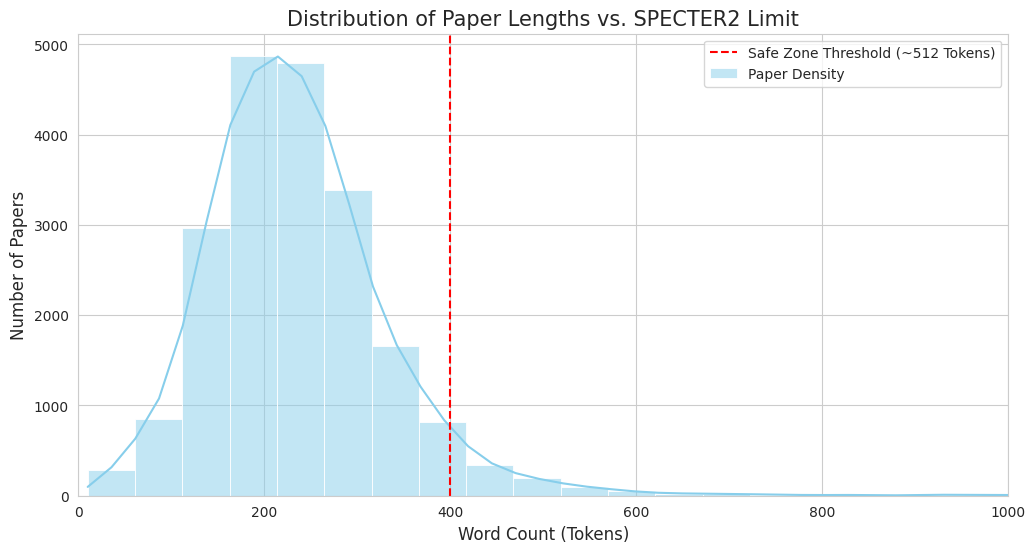

94.96% of your papers are within the safe zone.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# calculating word counts and storing it into a series object/column
word_counts = df['embedding_string'].str.split().str.len()

# 2. Setup the plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Create the histogram (limit x-axis to 1000 to see the detail)
sns.histplot(word_counts, bins=100, kde=True, color='skyblue', label='Paper Density')

# 4. Add the "Safe Zone" vertical line
# Using 400 as a conservative proxy for 512 sub-word tokens
plt.axvline(x=400, color='red', linestyle='--', label='Safe Zone Threshold (~512 Tokens)')

# 5. Formatting
plt.title('Distribution of Paper Lengths vs. SPECTER2 Limit', fontsize=15)
plt.xlabel('Word Count (Tokens)', fontsize=12)
plt.ylabel('Number of Papers', fontsize=12)
plt.xlim(0, 1000) # Clipping the x-axis so we can actually see the distribution
plt.legend()

plt.show()

# 6. Calculate exact percentage
safe_count = (word_counts <= 400).sum()
percentage = (safe_count / len(word_counts)) * 100
print(f"{percentage:.2f}% of your papers are within the safe zone.")

In [ ]:
from google.colab import files

df.to_csv('cleaned_metadata.csv')
files.download('cleaned_metadata.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>